In [56]:
import pandas as pd
import sqlite3

csv_path="/Users/indraniabbireddy/Documents/PROJECT_DA_PRACTICE/PORTFOLIO_GIT_PRACTICE/Executive Sales Performance Dashboard/Data/Sample - Superstore.csv"

connect=sqlite3.connect('store.db')

df_sales=pd.read_csv(csv_path,encoding='latin1')

df_sales.to_sql('sales',connect,if_exists='replace',index=False)

df_sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [71]:
#YoY Revenue & Margin by Region

query_yoy="""
select region,
substr("Order Date",length("Order Date")-3) as yr,
round(sum(sales),2) as total_sales,
round(sum(profit),2) as total_profit,
round(sum(profit)*100.0/sum(sales),2) as margin_pct
from sales 
group by region,yr
order by region,yr;
"""
    
#Pareto: top sub-categories driving 80% of profit

query_pareto=""" 
select "Sub-Category",
round(sum(profit),2) as profit,
round(sum(sum(profit)) over (order by sum(profit) desc 
rows between unbounded preceding and current row)*100.0/sum(sum(profit)) over(),2) as cumulative_pct
from sales
group by "Sub-Category" order by profit desc;
"""
    
# Key Insight: Discount impact on profitability
   
query_discount=""" 
select 
case 
    when discount = 0 then 'No Discount'
    when discount <=0.4 then 'Medium 20-40%'
    when discount <0.2 then 'Low 0-20%'
    else 'High >40%'
end as discount_band,
count(*) as orders,
round(avg(profit),2) as avg_profits,
round(avg(profit)*100.0/nullif(avg(sales),0),2) as avg_margin_pct
from sales
group by discount_band
order by avg_profits desc;
"""

df_yoy=pd.read_sql(query_yoy,connect)
df_pareto=pd.read_sql(query_pareto,connect)
df_discount=pd.read_sql(query_discount,connect)

df_yoy
df_pareto
df_discount

,discount_band,orders,avg_profits,avg_margin_pct
0,No Discount,4798,66.90,29.51
1,Medium 20-40%,4263,15.24,6.01
2,High >40%,933,-106.71,-77.40


💸 Profit lost from >40% discounts: $-99,559


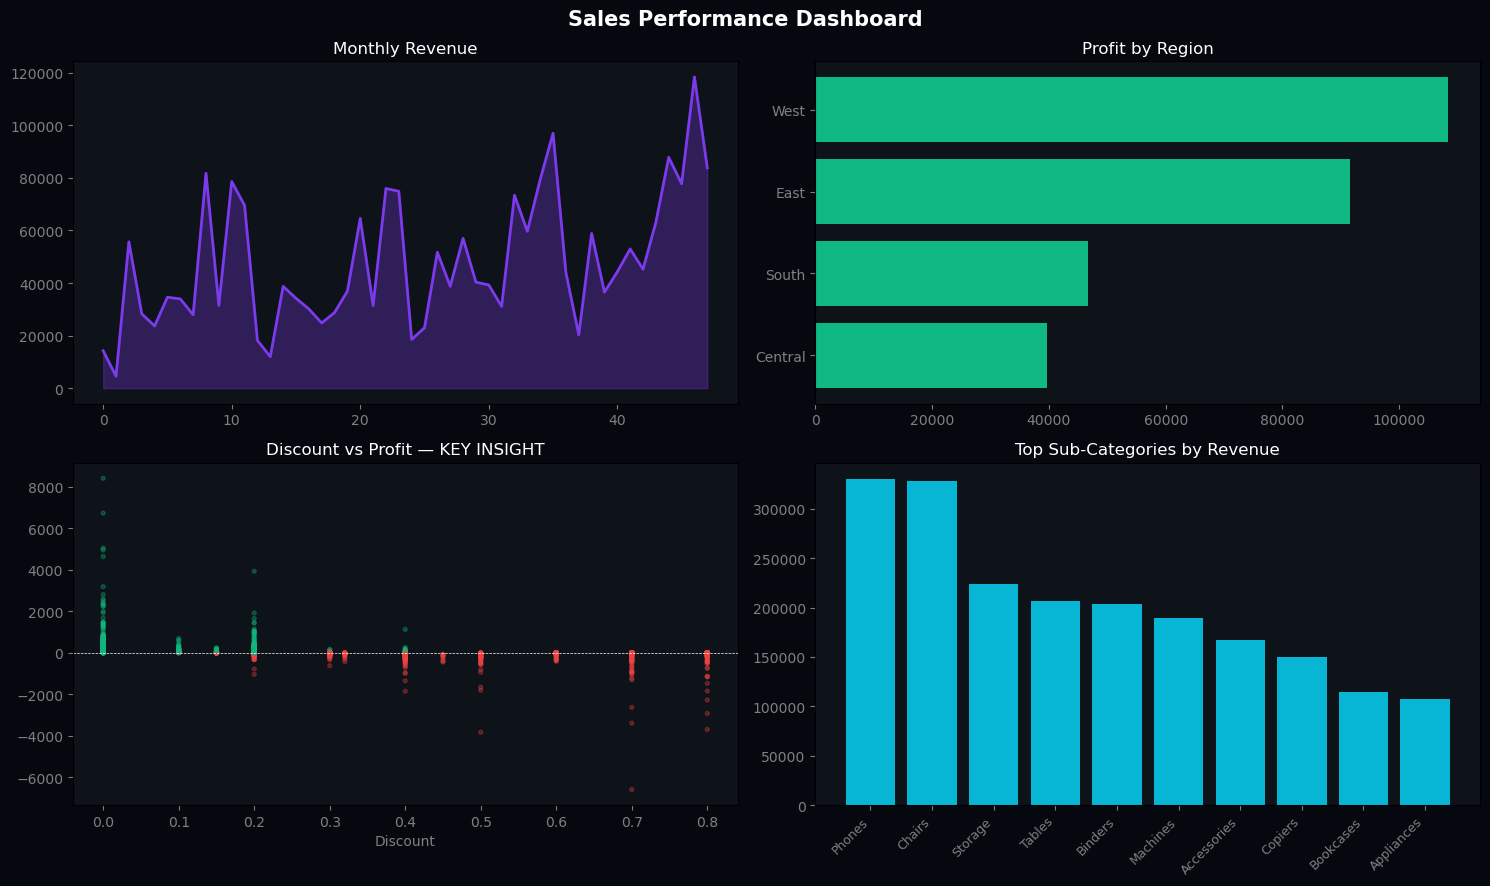

In [69]:
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("/Users/indraniabbireddy/Documents/PROJECT_DA_PRACTICE/PORTFOLIO_GIT_PRACTICE/Executive Sales Performance Dashboard/Data/Sample - Superstore.csv",encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['ym'] = df['Order Date'].dt.to_period('M')

fig, axes = plt.subplots(2,2, figsize=(15,9))
fig.patch.set_facecolor('#06080f')
fig.suptitle('Sales Performance Dashboard', color='white', fontsize=15, fontweight='bold')

#1. Monthly revenue trend with fill
m = df.groupby('ym')['Sales'].sum().reset_index()
m['ym'] = m['ym'].astype(str)
ax = axes[0,0]; ax.set_facecolor('#0e1219')
ax.fill_between(range(len(m)), m['Sales'], alpha=.3, color='#7c3aed')
ax.plot(range(len(m)), m['Sales'], color='#7c3aed', lw=2)
ax.set_title('Monthly Revenue', color='white'); ax.tick_params(colors='gray')

# 2. Profit by Region
rp = df.groupby('Region')['Profit'].sum().sort_values()
ax = axes[0,1]; ax.set_facecolor('#0e1219')
ax.barh(rp.index, rp.values, color=['#ef4444' if v<0 else '#10b981' for v in rp.values])
ax.set_title('Profit by Region', color='white'); ax.tick_params(colors='gray')

# 3. Discount vs Profit scatter (KEY CHART)
ax = axes[1,0]; ax.set_facecolor('#0e1219')
ax.scatter(df['Discount'], df['Profit'],
    c=['#10b981' if p>0 else '#ef4444' for p in df['Profit']], alpha=.3, s=8)
ax.axhline(0, color='white', lw=.5, ls='--')
ax.set_title('Discount vs Profit — KEY INSIGHT', color='white')
ax.set_xlabel('Discount', color='gray'); ax.tick_params(colors='gray')

# 4. Top sub-categories
ts = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)
ax = axes[1,1]; ax.set_facecolor('#0e1219')
ax.bar(range(len(ts)), ts.values, color='#06b6d4')
ax.set_xticks(range(len(ts))); ax.set_xticklabels(ts.index, rotation=45, ha='right', color='gray', fontsize=9)
ax.set_title('Top Sub-Categories by Revenue', color='white'); ax.tick_params(colors='gray')

plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, facecolor='#06080f')

loss = df[df['Discount']>0.4]['Profit'].sum()
print(f"💸 Profit lost from >40% discounts: ${loss:,.0f}")
